In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
GDP_REAL_PATH = "/content/drive/My Drive/Colab/KTĐC/Data/Tổng sản phẩm trong nước theo giá so sánh 2010 phân theo khu vực kinh tế chia theo Năm, Chỉ tiêu và Khu vực kinh tế.xlsx"
UNEMP_AGE_PATH = "/content/drive/My Drive/Colab/KTĐC/Data/Thất nghiệp.xlsx"
UNDEREMP_AGE_PATH = "/content/drive/My Drive/Colab/KTĐC/Data/Tỷ lệ thiếu việc làm trong độ tuổi lao động phân theo nhóm tuổi (2018 - 2024).xlsx"
INFORMAL_AGE_PATH = "/content/drive/My Drive/Colab/KTĐC/Data/Tỷ lệ lao động có việc làm phi chính thức phân theo nhóm tuổi (2018 - 2024).xlsx"
TRAINED_AGE_PATH = "/content/drive/My Drive/Colab/KTĐC/Data/Tỷ lệ lao động từ 15 tuổi trở lên đã qua đào tạo phân theo nhóm tuổi.xlsx"
LF_AGE_PATH = "/content/drive/My Drive/Colab/KTĐC/Data/Lực lượng lao động từ 15 tuổi trở lên phân theo nhóm tuổi.xlsx"

OUT_PATH = "content/drive/My Drive/Colab/KTĐC/Data/a077_panel_2018_2024_v2.csv"
YEARS = list(range(2018, 2025))

In [ ]:
import pandas as pd, numpy as np, re

#1) READ DATA

In [ ]:
def read_age_rate_table(path: str, sheet: str) -> pd.DataFrame:
    """
    Đọc bảng dạng:
      - dòng index=2: năm (2018..2024) từ cột 1 trở đi
      - cột 0: nhóm tuổi từ dòng index=3 trở đi
    Trả về dạng long: year, age, value
    """
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    years_raw = raw.iloc[2, 1:].tolist()
    years = [int(re.search(r"(\d{4})", str(x)).group(1)) for x in years_raw]
    ages = raw.iloc[3:, 0].astype(str).str.strip()
    vals = raw.iloc[3:, 1:].apply(pd.to_numeric, errors="coerce")
    vals.columns = years
    long = vals.copy()
    long.insert(0, "age", ages.values)
    long = long.melt(id_vars=["age"], var_name="year", value_name="value").dropna()
    long["year"] = long["year"].astype(int)
    return long

def read_labor_force_by_age(path: str, sheet: str) -> pd.DataFrame:
    """
    Đọc bảng labor force dạng:
      - dòng index=2: tiêu đề nhóm tuổi từ cột 2 trở đi
      - từ dòng index=3: cột 1 là năm (có thể có chữ), các cột sau là giá trị
    Trả về wide: year, [age groups...]
    """
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    age_headers = raw.iloc[2, 2:].astype(str).str.strip().tolist()
    df = raw.iloc[3:, 1:2+len(age_headers)].copy()
    df.columns = ["year_raw"] + age_headers

    df["year"] = df["year_raw"].astype(str).str.extract(r"(\d{4})")[0]
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df = df.dropna(subset=["year"]).copy()
    df["year"] = df["year"].astype(int)

    for c in age_headers:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df[["year"] + age_headers]

def load_gdp_growth(path: str, sheet: str="V03.03") -> pd.DataFrame:
    """
    Lấy GDP thực (giá SS 2010) Tổng số và tính tăng trưởng g_gdp = 100*Δln(GDP)
    """
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    df = raw.iloc[4:, [0,1]].copy()
    df.columns = ["year_raw", "gdp_total_real"]
    df["year"] = df["year_raw"].astype(str).str.extract(r"(\d{4})")[0].astype(int)
    df["gdp_total_real"] = pd.to_numeric(df["gdp_total_real"], errors="coerce")
    df = df.dropna().sort_values("year")
    df["g_gdp"] = 100*np.log(df["gdp_total_real"]).diff()
    return df[["year","g_gdp"]]

def to_wide(df_long: pd.DataFrame, value_col: str) -> pd.DataFrame:
    return df_long.pivot(index="year", columns="age", values=value_col).reset_index()

def mean_cols(df: pd.DataFrame, cols: list) -> pd.Series:
    return df[cols].mean(axis=1)

In [ ]:
unemp = read_age_rate_table(UNEMP_AGE_PATH, "V02.61").rename(columns={"value":"unemp_rate"})
underemp = read_age_rate_table(UNDEREMP_AGE_PATH, "V02.66").rename(columns={"value":"underemp_rate"})
informal = read_age_rate_table(INFORMAL_AGE_PATH, "V02.47").rename(columns={"value":"informal_rate"})
trained = read_age_rate_table(TRAINED_AGE_PATH, "V02.53").rename(columns={"value":"trained_rate"})
lf = read_labor_force_by_age(LF_AGE_PATH, "V02.36")
gdp = load_gdp_growth(GDP_REAL_PATH, "V03.03").query("year in @YEARS")

# to wide
U  = to_wide(unemp, "unemp_rate")
UE = to_wide(underemp, "underemp_rate")
INF = to_wide(informal, "informal_rate")
TR  = to_wide(trained, "trained_rate")

# 2) BUILD 15–24 SERIES

In [ ]:
U["u_15_24"] = U["15 - 24"]
UE["ue_15_24"] = UE["15 - 24"]
INF["inf_15_24"] = mean_cols(INF, ["15-19", "20-24"])
TR["tr_15_24"] = mean_cols(TR, ["15-19", "20-24"])

# 3) BUILD 25+ SERIES (weighted from 25–49 and 50+)

In [ ]:
U["u_25_49"] = U["25 - 49"]; U["u_50p"] = U["50+"]
UE["ue_25_49"] = UE["25 - 49"]; UE["ue_50p"] = UE["50+"]

cols_25_49 = ["25-29","30-34","35-39","40-44","45-49"]
INF["inf_25_49"] = mean_cols(INF, cols_25_49); INF["inf_50p"] = INF["50+"]
TR["tr_25_49"] = mean_cols(TR, cols_25_49); TR["tr_50p"] = TR["50+"]

lf = lf.query("year in @YEARS").copy()
lf = lf.rename(columns={"15 - 24":"lf_15_24","25 - 49":"lf_25_49","50+":"lf_50p"})
lf["lf_25p"] = lf["lf_25_49"] + lf["lf_50p"]

# merge base
base = pd.DataFrame({"year": YEARS})
base = base.merge(gdp, on="year", how="left")
base = base.merge(U[["year","u_15_24","u_25_49","u_50p"]], on="year", how="left")
base = base.merge(UE[["year","ue_15_24","ue_25_49","ue_50p"]], on="year", how="left")
base = base.merge(INF[["year","inf_15_24","inf_25_49","inf_50p"]], on="year", how="left")
base = base.merge(TR[["year","tr_15_24","tr_25_49","tr_50p"]], on="year", how="left")
base = base.merge(lf[["year","lf_15_24","lf_25_49","lf_50p","lf_25p"]], on="year", how="left")

w25, w50 = base["lf_25_49"], base["lf_50p"]
wsum = w25 + w50

base["u_25p"]  = (base["u_25_49"]*w25 + base["u_50p"]*w50)/wsum
base["ue_25p"] = (base["ue_25_49"]*w25 + base["ue_50p"]*w50)/wsum
base["inf_25p"]= (base["inf_25_49"]*w25 + base["inf_50p"]*w50)/wsum
base["tr_25p"] = (base["tr_25_49"]*w25 + base["tr_50p"]*w50)/wsum

# 4) STACK INTO PANEL (2 GROUPS)

In [ ]:
panel = pd.concat([
    base[["year","g_gdp","u_15_24","ue_15_24","inf_15_24","tr_15_24","lf_15_24"]]
      .rename(columns={"u_15_24":"unemp_rate",
                       "ue_15_24":"underemp_rate",
                       "inf_15_24":"informal_rate",
                       "tr_15_24":"trained_rate",
                       "lf_15_24":"labor_force"})
      .assign(group="15-24"),
    base[["year","g_gdp","u_25p","ue_25p","inf_25p","tr_25p","lf_25p"]]
      .rename(columns={"u_25p":"unemp_rate",
                       "ue_25p":"underemp_rate",
                       "inf_25p":"informal_rate",
                       "tr_25p":"trained_rate",
                       "lf_25p":"labor_force"})
      .assign(group="25+"),
], ignore_index=True).sort_values(["group","year"])

# 5) CREATE Δu WITHIN GROUP

In [ ]:
panel["du"] = panel.groupby("group")["unemp_rate"].diff()

# 6) SAVE File "a077_panel_2018_2024_v2.csv"

In [ ]:
import os

directory = os.path.dirname(OUT_PATH)
if not os.path.exists(directory):
    os.makedirs(directory, exist_ok=True)

panel.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print("Saved:", OUT_PATH)
print(panel.head)

Saved: content/drive/My Drive/Colab/KTĐC/Data/a077_panel_2018_2024_v2.csv
<bound method NDFrame.head of     year     g_gdp  unemp_rate  underemp_rate  informal_rate  trained_rate  \
0   2018  7.199508    6.920000       2.420000      77.285000     13.900000   
1   2019  7.101062    6.510000       2.440000      74.555000     13.150000   
2   2020  2.825129    7.210000       4.050000      73.970000     12.340000   
3   2021  2.521665    8.550000       3.890000      72.735000     14.855000   
4   2022  8.192554    7.780000       3.190000      68.315000     14.830000   
5   2023  4.858692    7.530000       2.720000      68.395000     12.685000   
6   2024  6.802821    7.920000       2.990000      69.670000     12.980000   
7   2018  7.199508    1.335251       1.478335      71.791756     22.615114   
8   2019  7.101062    1.328177       1.299967      71.324692     23.176590   
9   2020  2.825129    1.699742       2.250358      70.441826     24.728493   
10  2021  2.521665    2.421345       2

# Run



In [ ]:
import pandas as pd
from statsmodels.formula.api import ols

df = panel.dropna(subset=["du","g_gdp"]).copy()

# Chạy riêng theo nhóm tuổi
for g in ["15-24", "25+"]:
    m = ols("du ~ g_gdp", data=df[df["group"]==g]).fit(cov_type="HC1")
    print("\n===", g, "===")
    print(m.summary())

# Pooled + interaction (kiểm tra slope khác nhau)
m_pool = ols("du ~ g_gdp * C(group)", data=df).fit(cov_type="HC1")
print("\n=== pooled interaction ===")
print(m_pool.summary())


=== 15-24 ===
                            OLS Regression Results                            
Dep. Variable:                     du   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     16.81
Date:                Fri, 27 Mar 2026   Prob (F-statistic):             0.0149
Time:                        07:26:54   Log-Likelihood:                -2.8441
No. Observations:                   6   AIC:                             9.688
Df Residuals:                       4   BIC:                             9.272
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.6752      0.419     

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Các thư viện đang được sử dụng trong notebook này là:

*   `google.colab`
*   `pandas`
*   `numpy`
*   `re`
*   `os`
*   `statsmodels` (cụ thể là `statsmodels.formula.api`)
*   `matplotlib` (cụ thể là `matplotlib.pyplot`)

#Chạy: Phân rã & mô tả

In [ ]:
import pandas as pd
import numpy as np

df = panel

# pivot để có cột riêng cho 2 nhóm
wide = df.pivot(index="year", columns="group", values=["unemp_rate","trained_rate","informal_rate","underemp_rate","g_gdp"])
wide.columns = [f"{a}_{b}" for a,b in wide.columns]
wide = wide.reset_index()

# youth gap
wide["gap_youth"] = wide["unemp_rate_15-24"] - wide["unemp_rate_25+"]

# Δu
wide["du_15_24"] = wide["unemp_rate_15-24"].diff()
wide["du_25p"]   = wide["unemp_rate_25+"].diff()

# mô tả
desc_15 = wide["unemp_rate_15-24"].describe()
desc_25 = wide["unemp_rate_25+"].describe()

# tương quan (mô tả chu kỳ)
corr_15 = wide[["g_gdp_15-24","du_15_24"]].corr().iloc[0,1]   # g_gdp giống nhau nên lấy cột nào cũng được
corr_25 = wide[["g_gdp_25+","du_25p"]].corr().iloc[0,1]

print("Youth gap series:\n", wide[["year","gap_youth"]])
print("\nDescribe u_15-24:\n", desc_15)
print("\nDescribe u_25+:\n", desc_25)
print("\nCorr(g_gdp, Δu_15-24) =", corr_15)
print("Corr(g_gdp, Δu_25+)   =", corr_25)

Youth gap series:
    year  gap_youth
0  2018   5.584749
1  2019   5.181823
2  2020   5.510258
3  2021   6.128655
4  2022   6.188319
5  2023   6.035296
6  2024   6.381522

Describe u_15-24:
 count    7.000000
mean     7.488571
std      0.677973
min      6.510000
25%      7.065000
50%      7.530000
75%      7.850000
max      8.550000
Name: unemp_rate_15-24, dtype: float64

Describe u_25+:
 count    7.000000
mean     1.629911
std      0.373545
min      1.328177
25%      1.414978
50%      1.538478
75%      1.645711
max      2.421345
Name: unemp_rate_25+, dtype: float64

Corr(g_gdp, Δu_15-24) = -0.8408557329901097
Corr(g_gdp, Δu_25+)   = -0.854711689706077


# RQ1: Vẽ hình


In [ ]:
import pandas as pd

wide = df.pivot(index="year", columns="group", values="unemp_rate").reset_index()
wide["gap_youth"] = wide["15-24"] - wide["25+"]
print(wide)

group  year  15-24       25+  gap_youth
0      2018   6.92  1.335251   5.584749
1      2019   6.51  1.328177   5.181823
2      2020   7.21  1.699742   5.510258
3      2021   8.55  2.421345   6.128655
4      2022   7.78  1.591681   6.188319
5      2023   7.53  1.494704   6.035296
6      2024   7.92  1.538478   6.381522


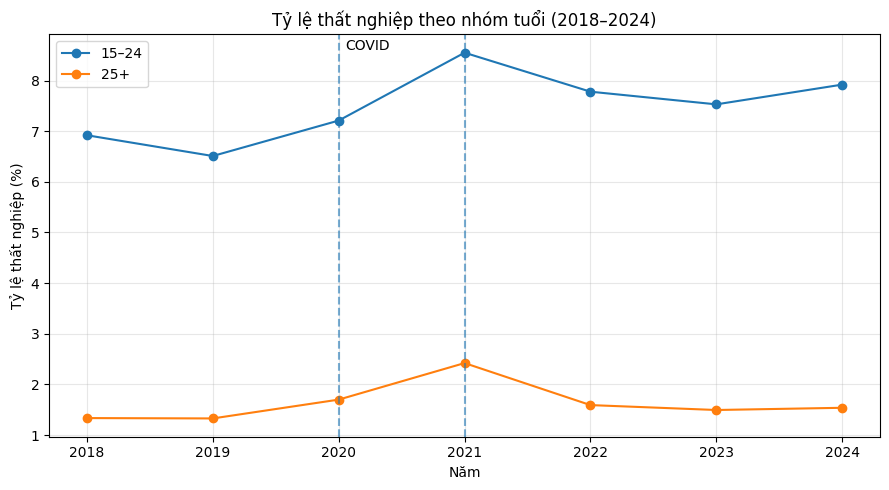

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(wide["year"], wide["15-24"], marker="o", label="15–24")
plt.plot(wide["year"], wide["25+"], marker="o", label="25+")

# đánh dấu giai đoạn COVID (tuỳ bạn giữ/ bỏ)
plt.axvline(2020, linestyle="--", alpha=0.6)
plt.axvline(2021, linestyle="--", alpha=0.6)
plt.text(2020.05, max(wide["15-24"].max(), wide["25+"].max()), "COVID", va="bottom")

plt.title("Tỷ lệ thất nghiệp theo nhóm tuổi (2018–2024)")
plt.xlabel("Năm")
plt.ylabel("Tỷ lệ thất nghiệp (%)")
plt.xticks(wide["year"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

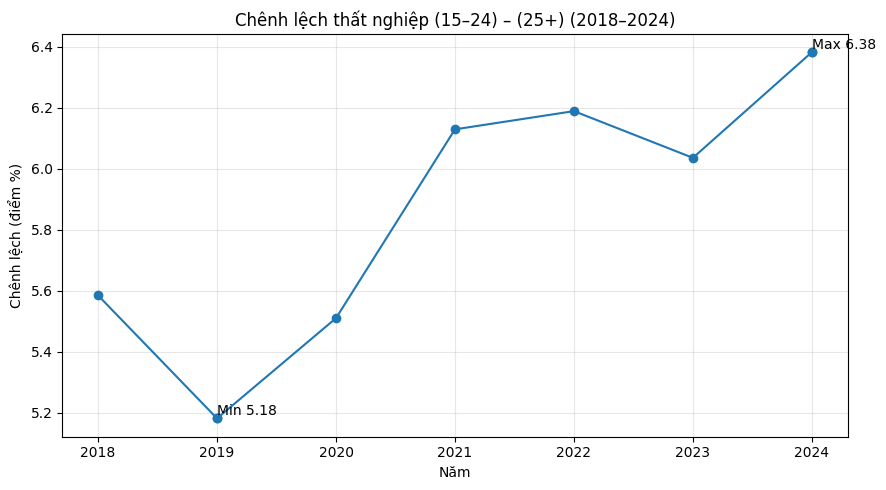

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(wide["year"], wide["gap_youth"], marker="o")

# ghi chú min/max cho thuyết trình
i_min = wide["gap_youth"].idxmin()
i_max = wide["gap_youth"].idxmax()
plt.scatter([wide.loc[i_min, "year"], wide.loc[i_max, "year"]],
            [wide.loc[i_min, "gap_youth"], wide.loc[i_max, "gap_youth"]])

plt.text(wide.loc[i_min, "year"], wide.loc[i_min, "gap_youth"],
         f"Min {wide.loc[i_min,'gap_youth']:.2f}", va="bottom")
plt.text(wide.loc[i_max, "year"], wide.loc[i_max, "gap_youth"],
         f"Max {wide.loc[i_max,'gap_youth']:.2f}", va="bottom")

plt.title("Chênh lệch thất nghiệp (15–24) – (25+) (2018–2024)")
plt.xlabel("Năm")
plt.ylabel("Chênh lệch (điểm %)")
plt.xticks(wide["year"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# RQ2: Vẽ hình


In [ ]:
import pandas as pd

wide = df.pivot(index="year", columns="group", values="unemp_rate").reset_index()

u15_2021 = wide.loc[wide["year"]==2021, "15-24"].iloc[0]
u15_2019 = wide.loc[wide["year"]==2019, "15-24"].iloc[0]
u25_2021 = wide.loc[wide["year"]==2021, "25+"].iloc[0]
u25_2019 = wide.loc[wide["year"]==2019, "25+"].iloc[0]

shock_15_24 = u15_2021 - u15_2019
shock_25p   = u25_2021 - u25_2019

u15_2024 = wide.loc[wide["year"]==2024, "15-24"].iloc[0]
u25_2024 = wide.loc[wide["year"]==2024, "25+"].iloc[0]

rec_15_24 = u15_2024 - u15_2021   # âm = giảm
rec_25p   = u25_2024 - u25_2021   # âm = giảm

print("Shock 2019→2021 (điểm %): 15–24 =", shock_15_24, " | 25+ =", shock_25p)
print("Recovery 2021→2024 (điểm %): 15–24 =", rec_15_24, " | 25+ =", rec_25p)
wide

Shock 2019→2021 (điểm %): 15–24 = 2.040000000000001  | 25+ = 1.0931678943011331
Recovery 2021→2024 (điểm %): 15–24 = -0.6300000000000008  | 25+ = -0.882866945858563


group,year,15-24,25+
0,2018,6.92,1.335251
1,2019,6.51,1.328177
2,2020,7.21,1.699742
3,2021,8.55,2.421345
4,2022,7.78,1.591681
5,2023,7.53,1.494704
6,2024,7.92,1.538478


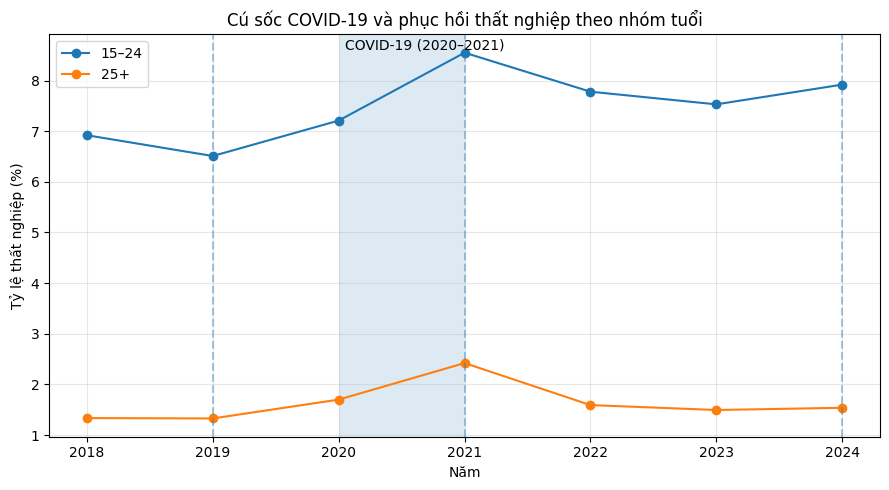

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.plot(wide["year"], wide["15-24"], marker="o", label="15–24")
plt.plot(wide["year"], wide["25+"], marker="o", label="25+")

# tô vùng COVID 2020–2021
plt.axvspan(2020, 2021, alpha=0.15)
plt.text(2020.05, max(wide["15-24"].max(), wide["25+"].max()), "COVID-19 (2020–2021)", va="bottom")

# đánh dấu các mốc
for y in [2019, 2021, 2024]:
    plt.axvline(y, linestyle="--", alpha=0.4)

plt.title("Cú sốc COVID-19 và phục hồi thất nghiệp theo nhóm tuổi")
plt.xlabel("Năm")
plt.ylabel("Tỷ lệ thất nghiệp (%)")
plt.xticks(wide["year"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

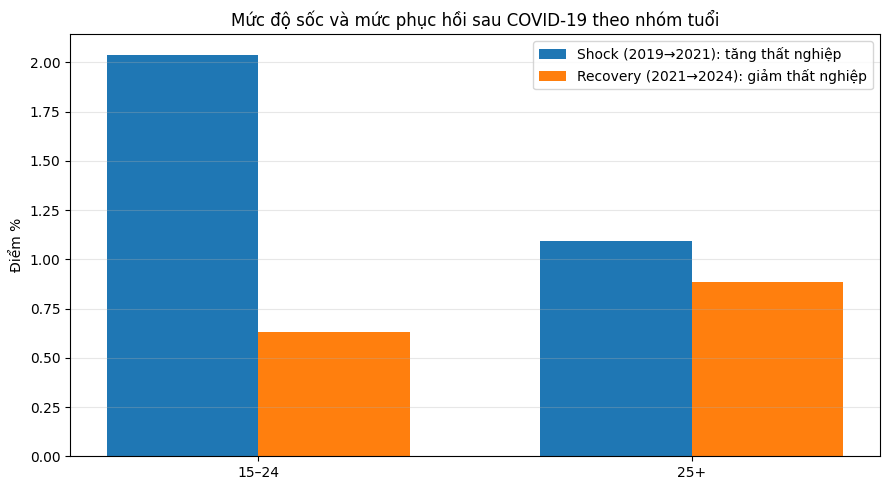

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

groups = ["15–24", "25+"]

shock = [shock_15_24, shock_25p]                 # dương: tăng thất nghiệp do sốc
recovery = [-rec_15_24, -rec_25p]                # đổi dấu để biểu diễn "mức giảm" sau sốc (dương là phục hồi)

x = np.arange(len(groups))
w = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - w/2, shock, width=w, label="Shock (2019→2021): tăng thất nghiệp")
plt.bar(x + w/2, recovery, width=w, label="Recovery (2021→2024): giảm thất nghiệp")

plt.xticks(x, groups)
plt.ylabel("Điểm %")
plt.title("Mức độ sốc và mức phục hồi sau COVID-19 theo nhóm tuổi")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#RQ4


In [ ]:
df = pd.read_excel("/content/drive/My Drive/Colab/KTĐC/Data/Tỷ lệ thất nghiệp trong độ tuổi lao động phân theo trình độ chuyên môn kỹ thuật chia theo Trình độ chuyên môn kỹ thuật và Năm.xlsx")
df

,Tỷ lệ thất nghiệp trong độ tuổi lao động phân theo trình độ chuyên môn kỹ thuật chia theo Trình độ chuyên môn kỹ thuật và Năm,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,2018,2019,2020,2021,2022,2023,Sơ bộ 2024
1,TỔNG SỐ,"2,19","2,17","2,48","3,2","2,34","2,28","2,24"
2,Không có trình độ CMKT,"2,06","2,03","1,9","3,25","2,21","2,01","2,31"
3,Sơ cấp,"1,26","1,08","2,27",2,"1,6","1,14","1,27"
4,Trung cấp,"2,62","2,18","4,12","2,66","2,31","1,72","1,6"
5,Cao đẳng,"3,77","3,79","6,07","4,43","3,41","2,69","2,81"
6,Đại học trở lên,"2,62","2,87","4,26","3,38","3,16","2,85","2,38"


In [ ]:
import pandas as pd

# đọc file
df = pd.read_excel(
    "/content/drive/My Drive/Colab/KTĐC/Data/Tỷ lệ thất nghiệp trong độ tuổi lao động phân theo trình độ chuyên môn kỹ thuật chia theo Trình độ chuyên môn kỹ thuật và Năm.xlsx",
    header=1
)

# đổi tên cột
df.columns = ["year","2018","2019","2020","2021","2022","2023","2024"]

# bỏ dòng rác (education = NaN)
df = df.dropna(subset=["year"])

# bỏ dòng tổng nếu có
df = df[df["year"] != "TỔNG SỐ"]

# reset index
df = df.reset_index(drop=True)

# chuyển dữ liệu sang float
years = ["2018","2019","2020","2021","2022","2023","2024"]

for y in years:
    df[y] = pd.to_numeric(
        df[y].astype(str).str.replace(",", "."),
        errors="coerce"
    )

print(df)

                     year  2018  2019  2020  2021  2022  2023  2024
0  Không có trình độ CMKT  2.06  2.03  1.90  3.25  2.21  2.01  2.31
1                  Sơ cấp  1.26  1.08  2.27  2.00  1.60  1.14  1.27
2               Trung cấp  2.62  2.18  4.12  2.66  2.31  1.72  1.60
3                Cao đẳng  3.77  3.79  6.07  4.43  3.41  2.69  2.81
4         Đại học trở lên  2.62  2.87  4.26  3.38  3.16  2.85  2.38


In [ ]:
years = ["2018","2019","2020","2021","2022","2023","2024"]

df["mean_unemployment"] = df[years].mean(axis=1)

result = df[["year","mean_unemployment"]].sort_values(
    by="mean_unemployment",
    ascending=False
)

print(result)

                     year  mean_unemployment
3                Cao đẳng           3.852857
4         Đại học trở lên           3.074286
2               Trung cấp           2.458571
0  Không có trình độ CMKT           2.252857
1                  Sơ cấp           1.517143


In [ ]:
gap = df[years].max() - df[years].min()

gap_df = gap.reset_index()
gap_df.columns = ["nam","chenh_lech"]

print(gap_df)

    nam  chenh_lech
0  2018        2.51
1  2019        2.71
2  2020        4.17
3  2021        2.43
4  2022        1.81
5  2023        1.71
6  2024        1.54


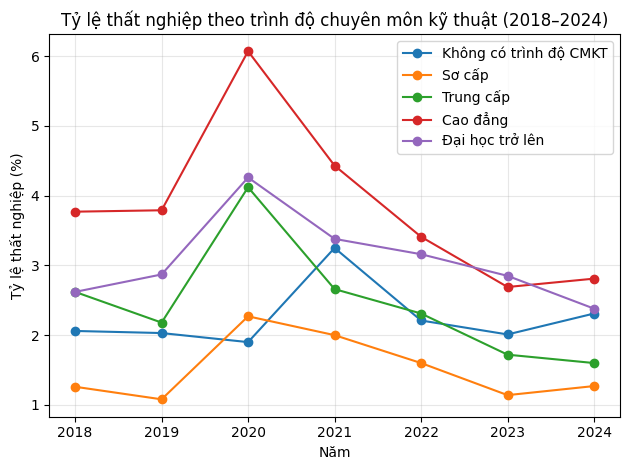

In [ ]:
import matplotlib.pyplot as plt

for i in range(len(df)):
    plt.plot(years, df.iloc[i][years], marker="o", label=df["year"].iloc[i])

plt.xlabel("Năm")
plt.ylabel("Tỷ lệ thất nghiệp (%)")
plt.title("Tỷ lệ thất nghiệp theo trình độ chuyên môn kỹ thuật (2018–2024)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()